# 1. Setup Libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

# 2. Carregamento

In [2]:
df = pd.read_csv("data/df_final.csv")
df = df.sort_values("ano").reset_index(drop=True)

# logs
df["log_pib"] = np.log(df["pib_ipea"])
df["log_social"] = np.log(df["gasto_social"])

# 3. ESTAÇÃO

In [3]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"{name} | p-value: {result[1]}")

adf_test(df["gini"], "Gini")
adf_test(df["log_pib"], "Log PIB")
adf_test(df["log_social"], "Log Social")

Gini | p-value: 0.8457778305051343
Log PIB | p-value: 0.8812041279203863
Log Social | p-value: 0.912323409655212


# 4. Tornar estacionário

In [4]:
df["dgini"] = df["gini"].diff()
df["dlog_pib"] = df["log_pib"].diff()
df["dlog_social"] = df["log_social"].diff()
df["dexport"] = df["export_pct_gdp"].diff()

df = df.dropna().reset_index(drop=True)

# 5. CAUSALIDADE DE GRANGER

In [5]:
print("PIB → Gini")
grangercausalitytests(df[["dgini", "dlog_pib"]], maxlag=2)

print("\nSocial → Gini")
grangercausalitytests(df[["dgini", "dlog_social"]], maxlag=2)

PIB → Gini

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=9.5579  , p=0.0149  , df_denom=8, df_num=1
ssr based chi2 test:   chi2=13.1421 , p=0.0003  , df=1
likelihood ratio test: chi2=8.6467  , p=0.0033  , df=1
parameter F test:         F=9.5579  , p=0.0149  , df_denom=8, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.7555  , p=0.1010  , df_denom=5, df_num=2
ssr based chi2 test:   chi2=15.0221 , p=0.0005  , df=2
likelihood ratio test: chi2=9.1717  , p=0.0102  , df=2
parameter F test:         F=3.7555  , p=0.1010  , df_denom=5, df_num=2

Social → Gini

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.8847  , p=0.0305  , df_denom=8, df_num=1
ssr based chi2 test:   chi2=9.4665  , p=0.0021  , df=1
likelihood ratio test: chi2=6.8299  , p=0.0090  , df=1
parameter F test:         F=6.8847  , p=0.0305  , df_denom=8, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.4076

{np.int64(1): ({'ssr_ftest': (np.float64(6.884749741038927),
    np.float64(0.030466299203545648),
    np.float64(8.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(9.466530893928525),
    np.float64(0.0020925472568770528),
    np.int64(1)),
   'lrtest': (np.float64(6.829852037992193),
    np.float64(0.008964669122320875),
    np.int64(1)),
   'params_ftest': (np.float64(6.884749741038928),
    np.float64(0.030466299203545648),
    np.float64(8.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.407607988633443),
    np.float64(0.11649863824873057),
    np.float64(5.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(13.630431954533774),
    np.float64(0.0010969562529754185),
    np.int64(2)),
   'lrtest': (np.float64(8.599502779587183),
    np.float64(0.01357193271380857),
    np.int64(2)),
   'params_ftest': (np.float64(3.407607988633443),
    np.float64(0.11649863824873057),
    np.float64(5.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
      

# 6. MODELO VAR

In [6]:
var_data = df[[
    "dgini",
    "dlog_pib",
    "dlog_social"
]]

model_var = VAR(var_data)

var_model = model_var.fit(1)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 02, May, 2026
Time:                     18:48:07
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -12.6248
Nobs:                     11.0000    HQIC:                  -13.3325
Log likelihood:           36.9988    FPE:                2.36610e-06
AIC:                     -13.0589    Det(Omega_mle):     9.33120e-07
--------------------------------------------------------------------
Results for equation dgini
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                 -1.585570         0.220550           -7.189           0.000
L1.dgini              -0.100759         0.189913           -0.531           0.596
L1.dlog_pib            4.616171         1.694654        

# 7. IMPULSE RESPONSE (IRF)

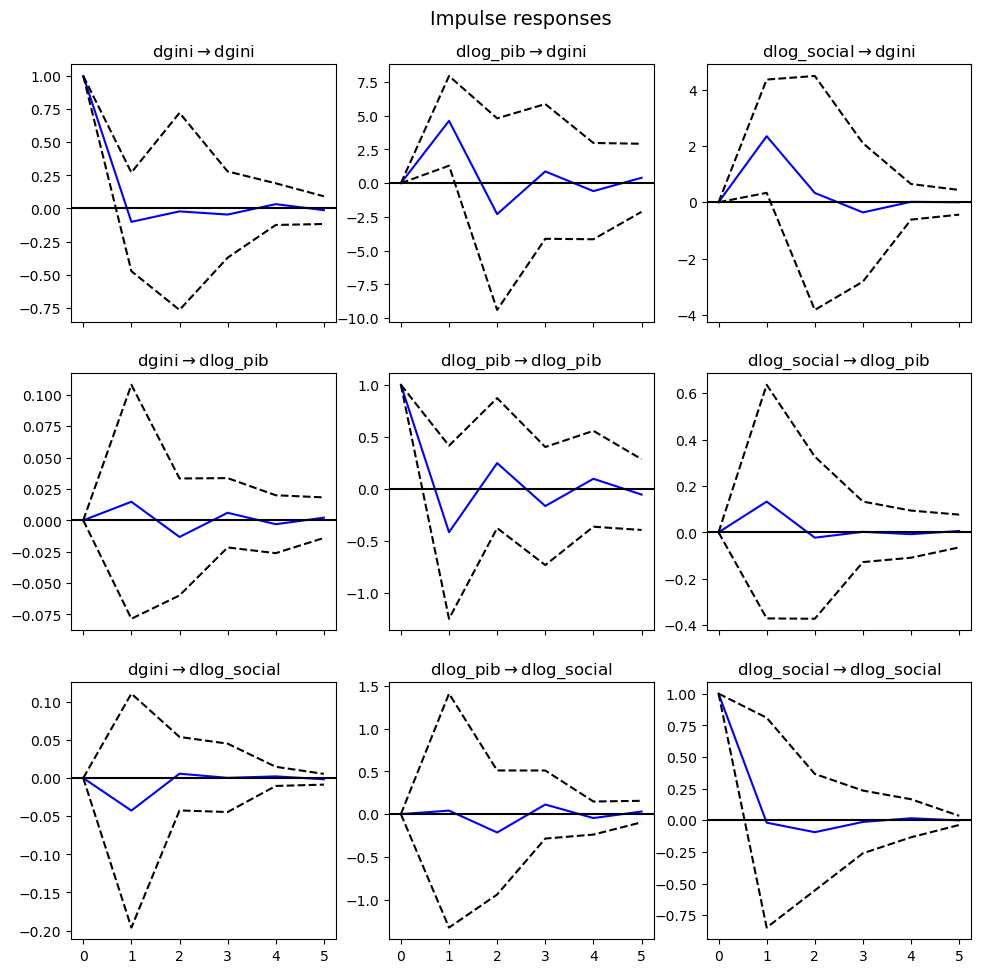

In [7]:
irf = var_model.irf(5)
irf.plot()
plt.show()

# 8. DECOMPOSIÇÃO DE VARIÂNCIA

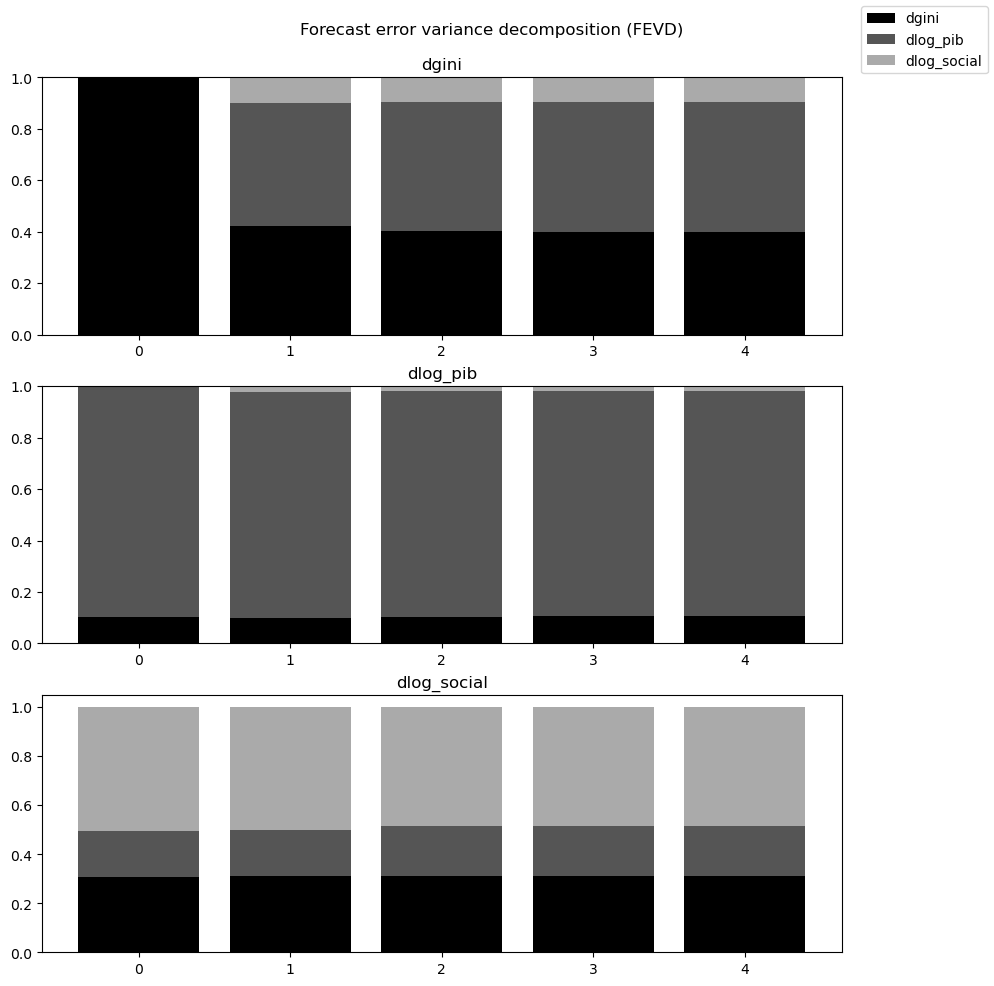

In [8]:
fevd = var_model.fevd(5)
fevd.plot()
plt.show()

# 9. MODELO ARDL SIMPLIFICADO

In [9]:
df["gini_lag1"] = df["gini"].shift(1)
df = df.dropna()

X = df[[
    "gini_lag1",
    "dlog_pib",
    "dlog_social"
]]

y = df["gini"]

X = sm.add_constant(X)
model_ardl = sm.OLS(y, X).fit()

print(model_ardl.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     49.52
Date:                Sat, 02 May 2026   Prob (F-statistic):           4.42e-05
Time:                        18:48:08   Log-Likelihood:                -4.4045
No. Observations:                  11   AIC:                             16.81
Df Residuals:                       7   BIC:                             18.40
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.6762      4.230      0.869      

# 10. DIAGNÓSTICO

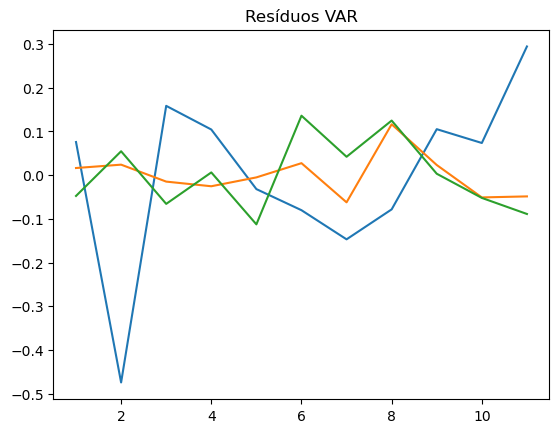

In [10]:
resid = var_model.resid

plt.figure()
plt.plot(resid)
plt.title("Resíduos VAR")
plt.show()